# Columnas desde DXF

Lee `section_01.dxf`, reporta areas pequenas/no identificadas y muestra dos casos de uso para `Estrato no identificado 1`: reasignarlo a un material existente y caracterizarlo con propiedades nuevas bajo otro nombre.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "src" / "dynaengine").exists():
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from dynaengine import (
    apply_material_aliases,
    extract_columns_from_dxf,
    filter_columns_with_unresolved_materials,
    plot_discretized_column,
    plot_dxf_extraction,
    plot_raw_column,
    prepare_column_configs,
    process_column_config,
    resolve_unidentified_materials_detailed,
)

DATA_DIR = ROOT / "examples" / "data"
DXF_PATH = DATA_DIR / "section_01.dxf"
MATERIALS_PATH = DATA_DIR / "section_01_materials.json"
TARGET_FREQUENCY_HZ = 25
SMALL_AREA_SCALE = 0.01
UNKNOWN_MATERIAL_NAME = "Estrato no identificado 1"
REASSIGNED_MATERIAL_NAME = "Grava pobremente gradada"
RENAMED_UNKNOWN_MATERIAL_NAME = "Grava pobremente gradada caracterizada"

x_positions_by_failure = {f"failure_{index}": [250.0, 480.0] for index in range(1, 8)}
failure_types = {name: "tipo_de_falla" for name in x_positions_by_failure}
x_positions = sorted({x for positions in x_positions_by_failure.values() for x in positions})

materials = json.loads(MATERIALS_PATH.read_text(encoding="utf-8"))
unknown_material_template = next(
    material for material in materials if material["material_name"] == UNKNOWN_MATERIAL_NAME
)
unknown_material_properties = {
    key: value for key, value in unknown_material_template.items() if key != "material_name"
}

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

print(f"Proyecto: {ROOT}")
print(f"Materiales cargados: {len(materials)}")
print(f"Plantilla del estrato no identificado: {UNKNOWN_MATERIAL_NAME}")

Proyecto: C:\Users\joel.alarcon\Desktop\_code\prismo\external\DynaEngine
Materiales cargados: 6
Plantilla del estrato no identificado: Estrato no identificado 1


Columnas extraidas: 2
Materiales en DXF: ['Estrato no identificado 1', 'Grava arcillosa', 'Grava arenosa', 'Grava pobremente gradada']
Estratos no identificados: ['Estrato no identificado 1']
Columna usada para ejemplos: section_01-failure_7-x480p0


### Fallas detectadas

,failure_id,failure_surface,failure_type,failure_height
0,1,failure_1,tipo_de_falla,14.38435
1,2,failure_2,tipo_de_falla,11.96292
2,3,failure_3,tipo_de_falla,10.23481
3,4,failure_4,tipo_de_falla,12.96041
4,5,failure_5,tipo_de_falla,18.25221
5,6,failure_6,tipo_de_falla,23.90455
6,7,failure_7,tipo_de_falla,16.90816


### Alertas de areas/materiales

,notification_type,material_name,polygon_id,area_m2,area_ratio_to_total,omitted_from_discretization,requires_material_resolution,bounds,representative_point
0,[unidentified_material],Estrato no identificado 1,9,1792.27472,0.04343,False,True,"[403.59899, 4172.62551, 484.97031, 4214.91671]","[455.86255, 4200.2415]"
1,[small_area_omitted],Material dique,7,334.17383,0.00810,True,False,"[301.34365, 4250.00012, 343.94842, 4264.9999]","[324.06206, 4256.84887]"
2,[small_area_omitted],Material de poza,6,132.32591,0.00321,True,False,"[235.50702, 4226.38146, 261.6096, 4235.4989]","[248.94228, 4229.00009]"
3,[small_area_omitted],Grava arenosa,10,3.48914,0.00008,True,False,"[301.61713, 4132.62551, 326.50229, 4142.59663]","[319.67445, 4137.64334]"


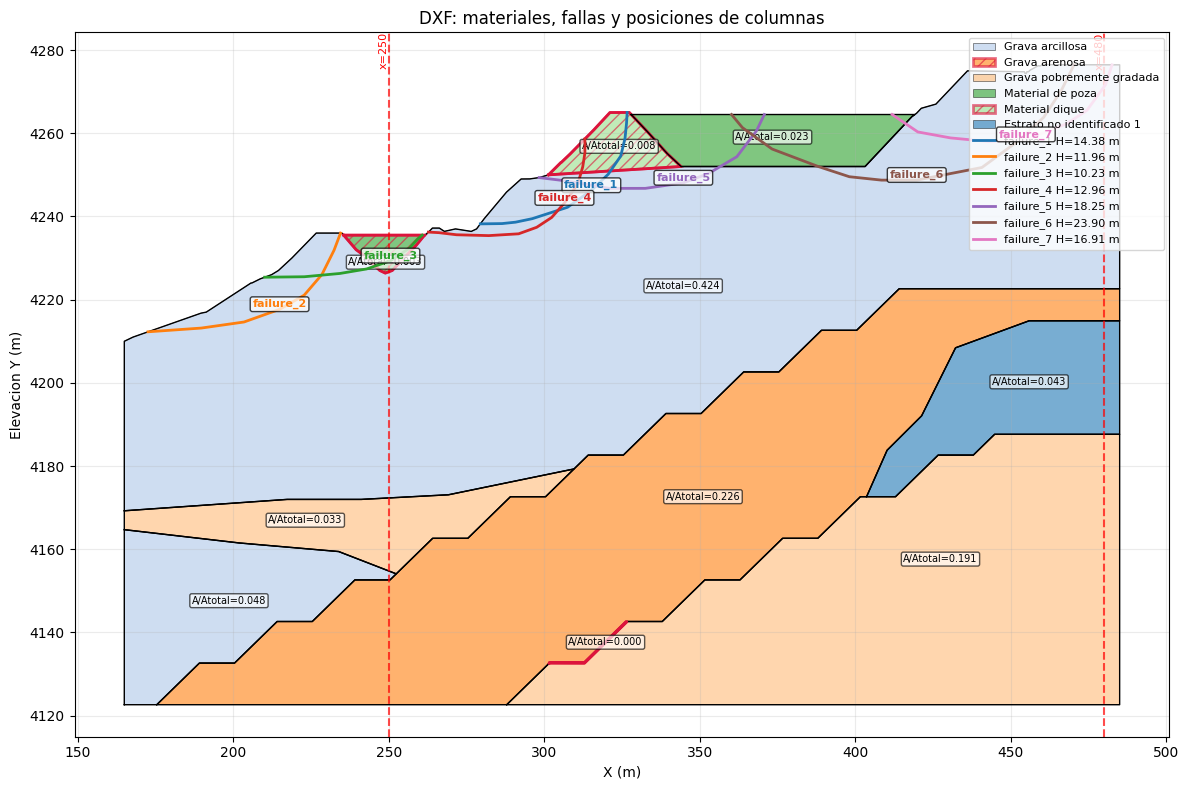

In [2]:
extraction = extract_columns_from_dxf(
    DXF_PATH,
    x_positions=x_positions_by_failure,
    failure_types=failure_types,
    small_area_scale=SMALL_AREA_SCALE,
)

column_with_unknown = next(
    name
    for name, column in extraction.columns.items()
    if any(layer["material"] == UNKNOWN_MATERIAL_NAME for layer in column["layers"])
)

print(f"Columnas extraidas: {len(extraction.columns)}")
print(f"Materiales en DXF: {extraction.material_names}")
print(f"Estratos no identificados: {extraction.unidentified_materials}")
print(f"Columna usada para ejemplos: {column_with_unknown}")

display(Markdown("### Fallas detectadas"))
display(pd.DataFrame(extraction.failure_surfaces.values())[[
    "failure_id", "failure_surface", "failure_type", "failure_height"
]])

area_notifications = pd.DataFrame(extraction.area_notifications)
display(Markdown("### Alertas de areas/materiales"))
display(area_notifications[[
    "notification_type",
    "material_name",
    "polygon_id",
    "area_m2",
    "area_ratio_to_total",
    "omitted_from_discretization",
    "requires_material_resolution",
    "bounds",
    "representative_point",
]] if not area_notifications.empty else area_notifications)

fig, ax = plot_dxf_extraction(
    extraction.clean_polygons,
    x_positions=x_positions,
    highlight_small_areas=True,
    small_area_scale=SMALL_AREA_SCALE,
    failure_polylines=extraction.failure_polylines,
    failure_surfaces=extraction.failure_surfaces,
    annotate_areas=True,
    annotate_x_positions=True,
)
ax.set_title("DXF: materiales, fallas y posiciones de columnas")
display(fig)
plt.close(fig)

In [3]:
def column_material_table(columns):
    return pd.DataFrame([
        {
            "column_name": name,
            "failure_surface": column["failure_surface"],
            "x_position_m": column["x_position"],
            "materials": " | ".join(layer["material"] for layer in column["layers"]),
        }
        for name, column in columns.items()
    ])


def resolve_columns(material_aliases=None, unidentified_actions=None):
    material_aliases = material_aliases or {}
    unidentified_actions = unidentified_actions or {}
    resolution = resolve_unidentified_materials_detailed(
        materials,
        extraction.unidentified_materials,
        actions=unidentified_actions,
        material_aliases=material_aliases,
    )
    all_aliases = {**material_aliases, **resolution.aliases}
    columns = apply_material_aliases(extraction.columns, all_aliases)
    columns, omitted_columns = filter_columns_with_unresolved_materials(
        columns,
        resolution.unresolved,
    )
    return resolution, columns, omitted_columns, all_aliases


def process_example_column(columns, resolved_materials):
    configs = prepare_column_configs(
        columns,
        resolved_materials,
        target_frequency_hz=TARGET_FREQUENCY_HZ,
    )
    return process_column_config(configs[column_with_unknown], calibrate=False)


def show_example_result(title, columns, result):
    display(Markdown(f"### {title}"))
    display(column_material_table({column_with_unknown: columns[column_with_unknown]}))
    display(result.raw[[
        "layer_id",
        "material_name",
        "top_m",
        "bottom_m",
        "thickness_m",
        "shear_velocity_m_s",
    ]])
    display(result.discretized.groupby(["source_layer_id", "material_name"], as_index=False).agg(
        segments=("segment_id", "count"),
        top_m=("top_m", "min"),
        bottom_m=("bottom_m", "max"),
        min_frequency_hz=("natural_frequency_hz", "min"),
        max_frequency_hz=("natural_frequency_hz", "max"),
    ))
    fig, ax = plot_raw_column(result.raw, figsize=(4, 7))
    ax.set_title(title)
    display(fig)
    plt.close(fig)
    fig, ax = plot_discretized_column(result.discretized, figsize=(4, 7))
    ax.set_title(f"{title} - discretizada")
    display(fig)
    plt.close(fig)

Alias aplicados: {'Estrato no identificado 1': 'Grava pobremente gradada'}
Columnas omitidas: []


### Caso 1 - Reasignado a Grava pobremente gradada

,column_name,failure_surface,x_position_m,materials
0,section_01-failure_7-x480p0,failure_7,480.0,Grava arcillosa | Grava arenosa | Grava pobrem...


,layer_id,material_name,top_m,bottom_m,thickness_m,shear_velocity_m_s
0,1,Grava arcillosa,0.00000,53.82763,53.82763,391.165464
1,2,Grava arenosa,53.82763,61.53603,7.70840,700.000000
2,3,Grava pobremente gradada,61.53603,88.82723,27.29120,500.000000
3,4,Grava pobremente gradada,88.82723,153.82703,64.99980,500.000000


,source_layer_id,material_name,segments,top_m,bottom_m,min_frequency_hz,max_frequency_hz
0,1,Grava arcillosa,27,0.00000,53.82763,25.080056,75.240169
1,2,Grava arenosa,2,53.82763,61.53603,45.405013,45.405013
2,3,Grava pobremente gradada,6,61.53603,88.82723,27.481386,27.481386
3,4,Grava pobremente gradada,13,88.82723,153.82703,25.000077,25.000077


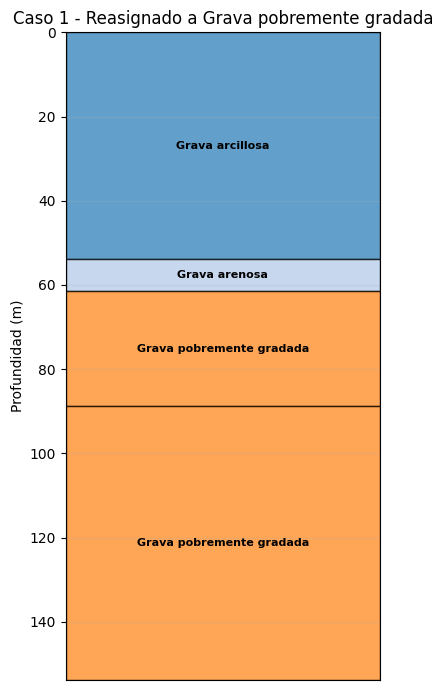

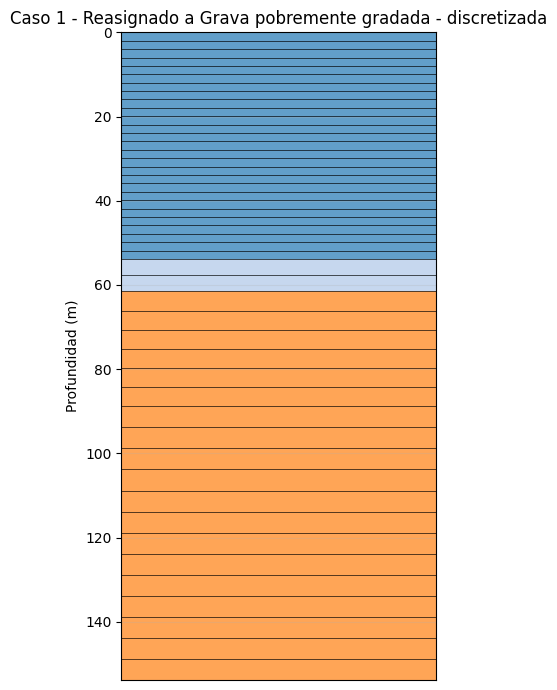

In [4]:
# Caso 1: reasignar el estrato no identificado a un material existente.
# Aqui el estrato DXF se trata como Grava pobremente gradada.
reassign_aliases = {
    UNKNOWN_MATERIAL_NAME: REASSIGNED_MATERIAL_NAME,
}
reassign_resolution, reassign_columns, reassign_omitted, reassign_all_aliases = resolve_columns(
    material_aliases=reassign_aliases,
)
reassign_result = process_example_column(
    reassign_columns,
    reassign_resolution.materials,
)

print(f"Alias aplicados: {reassign_all_aliases}")
print(f"Columnas omitidas: {reassign_omitted}")
show_example_result(
    f"Caso 1 - Reasignado a {REASSIGNED_MATERIAL_NAME}",
    reassign_columns,
    reassign_result,
)

Alias aplicados: {'Estrato no identificado 1': 'Grava pobremente gradada caracterizada'}
Columnas omitidas: []


### Material caracterizado con nombre nuevo

,unit_weight_kn_m3,shear_velocity,shear_properties,dynamic_model,material_name
0,19.0,"{'depth': [0, 24, 30, 35], 'vs': [230, 300, 44...","{'c': 0, 'phi': 34}","{'model_type': 'rojas_2019', 'sigma_vertical':...",Grava pobremente gradada caracterizada


### Caso 2 - Caracterizado como Grava pobremente gradada caracterizada

,column_name,failure_surface,x_position_m,materials
0,section_01-failure_7-x480p0,failure_7,480.0,Grava arcillosa | Grava arenosa | Grava pobrem...


,layer_id,material_name,top_m,bottom_m,thickness_m,shear_velocity_m_s
0,1,Grava arcillosa,0.00000,53.82763,53.82763,391.165464
1,2,Grava arenosa,53.82763,61.53603,7.70840,700.000000
2,3,Grava pobremente gradada caracterizada,61.53603,88.82723,27.29120,550.000000
3,4,Grava pobremente gradada,88.82723,153.82703,64.99980,500.000000


,source_layer_id,material_name,segments,top_m,bottom_m,min_frequency_hz,max_frequency_hz
0,1,Grava arcillosa,27,0.00000,53.82763,25.080056,75.240169
1,2,Grava arenosa,2,53.82763,61.53603,45.405013,45.405013
2,3,Grava pobremente gradada caracterizada,5,61.53603,88.82723,25.191270,25.191270
3,4,Grava pobremente gradada,13,88.82723,153.82703,25.000077,25.000077


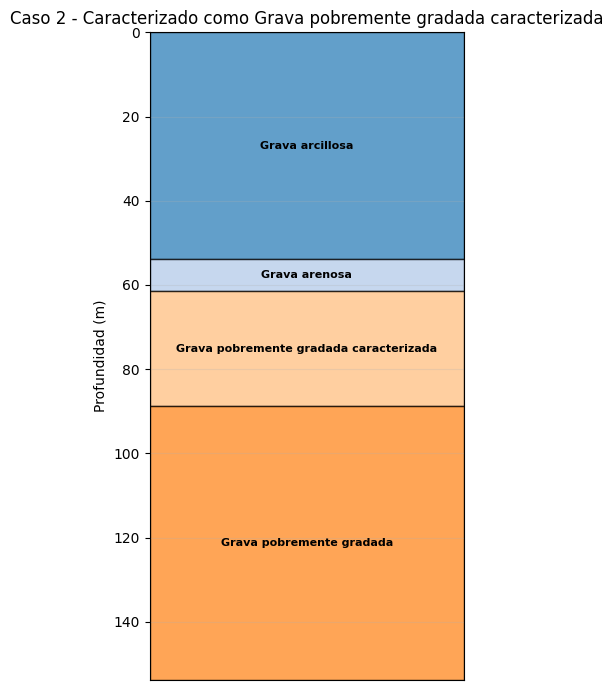

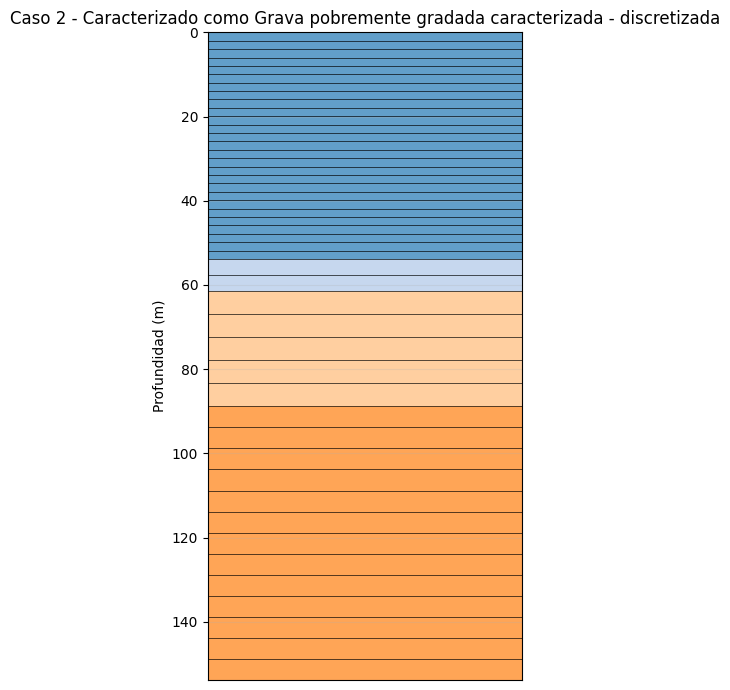

In [5]:
# Caso 2: caracterizar el estrato no identificado y nombrarlo de nuevo.
# Se usan las propiedades que ya vienen en section_01_materials.json para
# Estrato no identificado 1, pero el material final queda con un nombre trazable.
characterize_actions = {
    UNKNOWN_MATERIAL_NAME: {
        "action": "characterize",
        "name": RENAMED_UNKNOWN_MATERIAL_NAME,
        "properties": unknown_material_properties,
    }
}
characterized_resolution, characterized_columns, characterized_omitted, characterized_all_aliases = resolve_columns(
    unidentified_actions=characterize_actions,
)
characterized_result = process_example_column(
    characterized_columns,
    characterized_resolution.materials,
)

new_material = next(
    material
    for material in characterized_resolution.materials
    if material["material_name"] == RENAMED_UNKNOWN_MATERIAL_NAME
)

print(f"Alias aplicados: {characterized_all_aliases}")
print(f"Columnas omitidas: {characterized_omitted}")
display(Markdown("### Material caracterizado con nombre nuevo"))
display(pd.DataFrame([new_material]))
show_example_result(
    f"Caso 2 - Caracterizado como {RENAMED_UNKNOWN_MATERIAL_NAME}",
    characterized_columns,
    characterized_result,
)